In [5]:
# Nearest Neighbor and the Curse of Dimensionality
import numpy as np
from sklearn import datasets
iris_X, iris_y = datasets.load_iris(return_X_y=True)
np.unique(iris_y)

# Split iris data in train and test data
# A random permutation, to split the data randomly
np.random.seed(0)
indices = np.random.permutation(len(iris_X))
iris_X_train = iris_X[indices[:-10]]
iris_y_train = iris_y[indices[:-10]]
iris_X_test = iris_X[indices[-10:]]
iris_y_test = iris_y[indices[-10:]]
# Create and fit a nearest-neighbor classifier
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(iris_X_train, iris_y_train)
print(knn.predict(iris_X_test))
print(iris_y_test)

[1 2 1 0 0 0 2 1 2 0]
[1 1 1 0 0 0 2 1 2 0]


In [23]:
# Exercise 1 and 2
from sklearn import datasets, linear_model
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

X_digits, y_digits = datasets.load_digits(return_X_y=True)
X_digits = X_digits / X_digits.max()

num_samples = X_digits.shape[0]

np.random.seed(0)
X_digits_train = X_digits[: int(0.9 * num_samples)]
y_digits_train = y_digits[: int(0.9 * num_samples)]
X_digits_test = X_digits[int(0.9 * num_samples) :]
y_digits_test = y_digits[int(0.9 * num_samples) :]

# KNN
knn = KNeighborsClassifier()
knn.fit(X_digits_train, y_digits_train)
print("KNN Accuracy: {:.2f}".format(knn.score(X_digits_test, y_digits_test)))

# Linear Regressor
regr = linear_model.LogisticRegression()
regr.fit(X_digits_train, y_digits_train)
print("Linear Accuracy: {:.2f}".format(regr.score(X_digits_test, y_digits_test)))

KNN Accuracy: 0.96
Linear Accuracy: 0.93


SVC with linear kernel: 0.5555555555555556
LinearSVC (linear kernel): 0.6666666666666666
SVC with RBF kernel: 0.6666666666666666
SVC with polynomial (degree 3) kernel: 0.6666666666666666


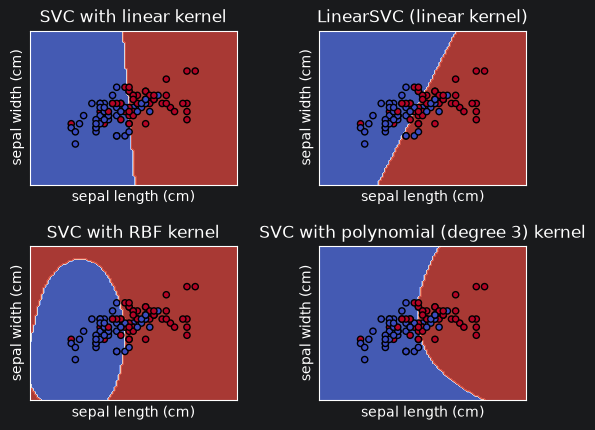

In [40]:
# Exercise 3
from sklearn import datasets, linear_model, svm
from sklearn.inspection import DecisionBoundaryDisplay
import numpy as np
import matplotlib.pyplot as plt

iris = datasets.load_iris()
X = iris.data
y = iris.target

X = X[y != 0, :2]
y = y[y != 0]

num_samples = X.shape[0]

indices = np.random.permutation(num_samples)
X = X[indices]
y = y[indices].astype(float)

np.random.seed(0)
X_train = X[indices[: int(0.9 * num_samples)]]
y_train = y[indices[: int(0.9 * num_samples)]]
X_test = X[indices[int(0.9 * num_samples)] :]
y_test = y[indices[int(0.9 * num_samples)] :]

C = 1.0
models = (
    svm.SVC(kernel="linear", C=C),
    svm.LinearSVC(C=C, max_iter=1000, dual="auto"),
    svm.SVC(kernel="rbf", gamma=0.7, C=C),
    svm.SVC(kernel='poly', degree=3, gamma="auto", C=C)
)
models = (clf.fit(X_train, y_train) for clf in models)
# for model in models:
#     print(model.score(X_test, y_test))

titles = (
    "SVC with linear kernel",
    "LinearSVC (linear kernel)",
    "SVC with RBF kernel",
    "SVC with polynomial (degree 3) kernel",
)

fig, sub = plt.subplots(2, 2)
plt.subplots_adjust(wspace=0.4, hspace=0.4)

X0, X1 = X[:, 0], X[:, 1]

for clf, title, ax in zip(models, titles, sub.flatten()):
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        response_method="predict",
        cmap=plt.cm.coolwarm,
        alpha=0.8,
        ax=ax,
        xlabel=iris.feature_names[0],
        ylabel=iris.feature_names[1],
    )
    ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)
    print(f"{title}: {clf.score(X_test, y_test)}")

plt.show()